# Notebook 03. Modelo Random Forest con validación espacial

Este notebook entrena un clasificador binario que asigna a cada celda una probabilidad de corresponder a asentamiento informal. Se eligió Random Forest por su robustez con etiquetas potencialmente ruidosas, su interpretabilidad vía feature importance, y su eficiencia computacional. La validación se hace con cross-validation sobre bloques geográficos usando GroupKFold, lo que garantiza que cada fold de prueba esté en una zona distinta a la de entrenamiento y previene el data leakage espacial que arrastra el split aleatorio típico. Las probabilidades de salida se calibran con el método de Platt (sigmoid) para que sean interpretables como probabilidades reales y no como simples scores.


## 0. Setup

In [ ]:
import sys
import warnings
import pickle
from pathlib import Path
warnings.filterwarnings("ignore")

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

from src.config import (
    DATA_PROC, OUTPUTS_RESULTS, OUTPUTS_MAPS,
    RANDOM_STATE, N_ESTIMATORS, CRS_TRABAJO,
)
from src.modeling import (
    construir_split_geografico, validacion_cruzada_espacial, threshold_optimo_f1,
)

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, roc_curve,
)

## 1. Cargar tabla maestra

In [ ]:
df = gpd.read_file(DATA_PROC / "tabla_maestra_features.gpkg")
print(f"Tabla maestra: {len(df):,} celdas · {df.shape[1]} columnas")

# Añadir centroides para split espacial
df["centroid_x"] = df.geometry.centroid.x
df["centroid_y"] = df.geometry.centroid.y

Tabla maestra: 8,902 celdas · 34 columnas


## 2. Definir variables predictoras (features)

In [ ]:
FEATURES = [
    # Espectrales Sentinel-2
    "B2", "B3", "B4", "B8", "B11", "B12",
    "NDVI", "NDBI", "NDWI", "BSI",
    # SAR Sentinel-1
    "VV", "VH", "VH_VV_diff_db",
    # Producto JRC
    "ghs_built",
    # Luces nocturnas
    "viirs_radiance",
    # Topografía
    "elevacion", "pendiente_grados",
    # Población
    "poblacion",
    # OSM vías
    "vias_long_m", "dist_via_principal_m",
    # OSM edificios
    "n_edificios", "area_total_m2", "area_media_m2", "area_std_m2", "compacidad_media",
]

# Limpieza básica: imputar SOLO las features con la mediana, preservando NaN en `etiqueta`
# (los NaN en etiqueta son intencionales: marcan las celdas sin etiqueta, para inferencia).
df_clean = df[FEATURES + ["etiqueta", "cell_id", "centroid_x", "centroid_y"]].copy()
df_clean[FEATURES] = df_clean[FEATURES].replace([np.inf, -np.inf], np.nan)
df_clean[FEATURES] = df_clean[FEATURES].fillna(df_clean[FEATURES].median(numeric_only=True))

print(f"Features utilizadas: {len(FEATURES)}")
print(f"Filas totales: {len(df_clean):,}")
print(f"Filas con etiqueta no nula (para entrenamiento): {df_clean['etiqueta'].notna().sum():,}")
print(f"Filas sin etiqueta (para inferencia): {df_clean['etiqueta'].isna().sum():,}")

Features utilizadas: 25
Filas totales: 8,902
Filas con etiqueta no nula (para entrenamiento): 2,781
Filas sin etiqueta (para inferencia): 6,121


## 3. Conjunto de entrenamiento (etiquetadas)

In [ ]:
df_train = df_clean[df_clean["etiqueta"].notna()].copy()
X = df_train[FEATURES].values
y = df_train["etiqueta"].astype(int).values

print(f"Conjunto de entrenamiento: {len(df_train):,} celdas")
print(f" -Positivos (informal preliminar): {(y == 1).sum():,}")
print(f"-Negativos (barrios formales):     {(y == 0).sum():,}")

Conjunto de entrenamiento: 2,781 celdas
 -Positivos (informal preliminar): 1,095
-Negativos (barrios formales):     1,686


## 4. Validación cruzada espacial

Se construye una grilla geográfica de 4×4 bloques sobre el área de estudio y se aplica GroupKFold. Cada fold de prueba contiene celdas geográficamente distintas a las del entrenamiento, lo que estima la generalización honesta del modelo a zonas no vistas. Esta es la métrica que se reporta en la nota técnica.


In [ ]:
grupos = construir_split_geografico(df_train, n_bloques=4, semilla=RANDOM_STATE)
print(f"Bloques espaciales únicos en el conjunto de entrenamiento: {len(np.unique(grupos))}")

Bloques espaciales únicos en el conjunto de entrenamiento: 15


In [ ]:
modelo_base = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

print("\nValidación cruzada espacial:")
resultados_cv = validacion_cruzada_espacial(X, y, grupos, modelo_base, verbose=True)

print("\nResumen métricas (media ± std):")
for k, vals in resultados_cv.items():
    vals = [v for v in vals if not np.isnan(v)]
    print(f"  {k}: {np.mean(vals):.3f} ± {np.std(vals):.3f}")


Validación cruzada espacial:
  Fold 1: F1=0.022  Prec=0.014  Recall=0.062
  Fold 2: F1=0.336  Prec=0.575  Recall=0.237
  Fold 3: F1=0.723  Prec=0.771  Recall=0.680
  Fold 4: F1=0.945  Prec=1.000  Recall=0.896
  Fold 5: F1=0.677  Prec=0.866  Recall=0.556

Resumen métricas (media ± std):
  f1: 0.541 ± 0.324
  auc: 0.784 ± 0.161
  precision: 0.645 ± 0.345
  recall: 0.486 ± 0.301


## 5. Entrenamiento del modelo final

Una vez validado el modelo con la cross-validation espacial, se entrena sobre el conjunto etiquetado completo (positivos más negativos) y se envuelve en un CalibratedClassifierCV con método sigmoid para producir probabilidades interpretables. El modelo entrenado se persiste en disco para que pueda reutilizarse en inferencias futuras sin reentrenar.


In [ ]:
modelo = CalibratedClassifierCV(
    RandomForestClassifier(
        n_estimators=N_ESTIMATORS,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    method="sigmoid",
    cv=3,
)
modelo.fit(X, y)
print("(Ok) Modelo entrenado")

# Persistir modelo
with open(OUTPUTS_RESULTS / "modelo_rf_calibrado.pkl", "wb") as f:
    pickle.dump({"modelo": modelo, "features": FEATURES}, f)

(Ok) Modelo entrenado


## 6. Importancia de variables

Feature importance promediada de los árboles internos del RF.

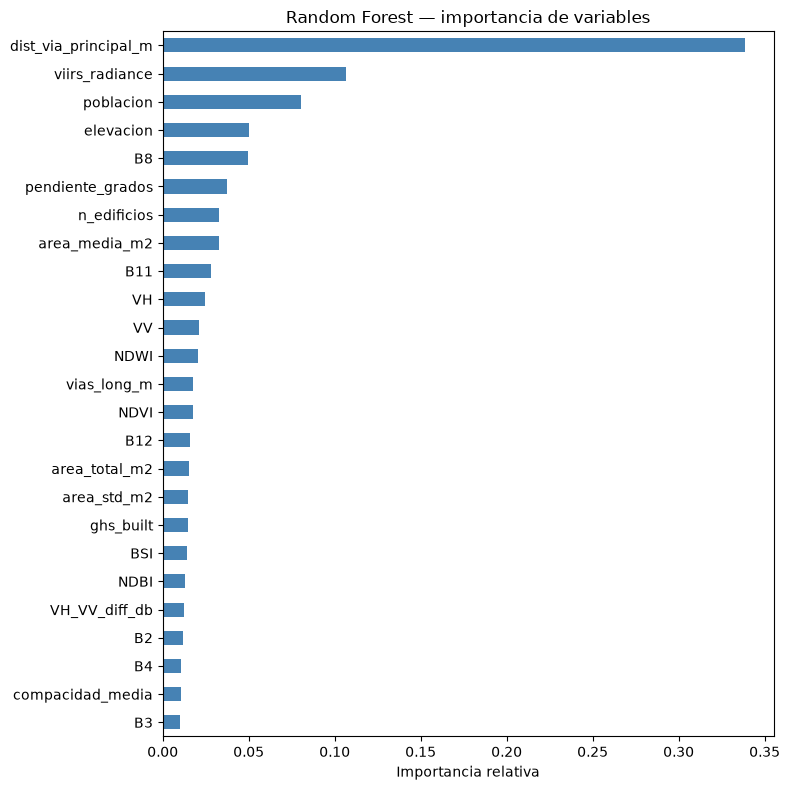


Top-10 variables más importantes:
dist_via_principal_m    0.338
viirs_radiance          0.106
poblacion               0.080
elevacion               0.050
B8                      0.050
pendiente_grados        0.037
n_edificios             0.033
area_media_m2           0.032
B11                     0.028
VH                      0.025
dtype: float64


In [ ]:
# Acceder a los estimadores internos del CalibratedClassifierCV
rf_interno = modelo.calibrated_classifiers_[0].estimator
importancias = pd.Series(rf_interno.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
importancias.plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Importancia relativa")
ax.set_title("Random Forest — importancia de variables")
plt.tight_layout()
plt.savefig(OUTPUTS_MAPS / "fig_feature_importance.png", dpi=140)
plt.show()

print("\nTop-10 variables más importantes:")
print(importancias.sort_values(ascending=False).head(10).round(3))

## 7. Curvas ROC y Precision-Recall

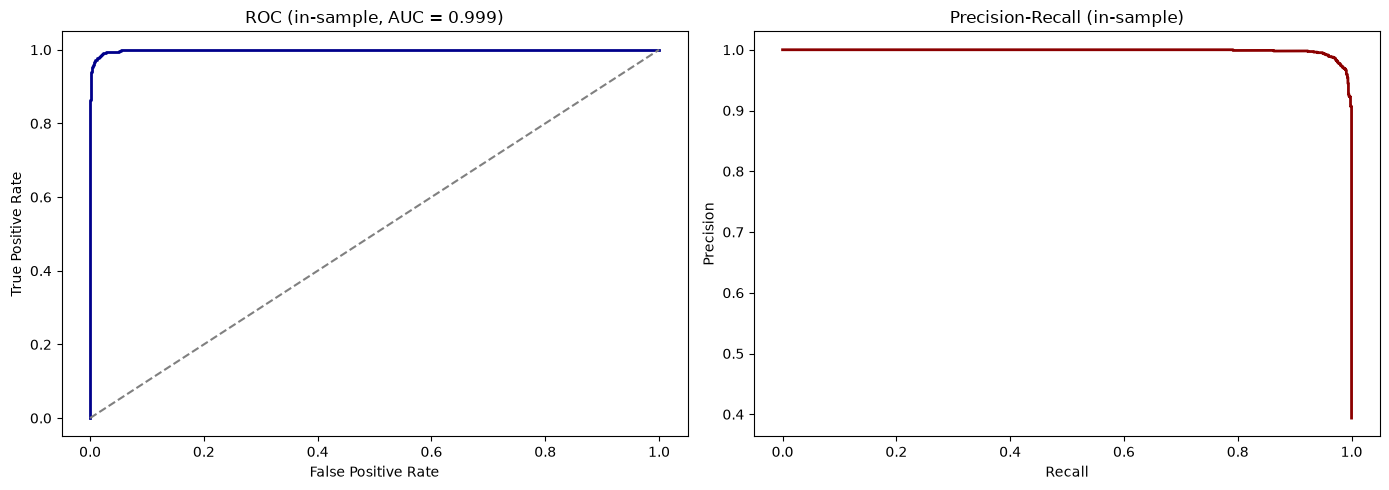

In [ ]:
y_proba_train = modelo.predict_proba(X)[:, 1]
fpr, tpr, _ = roc_curve(y, y_proba_train)
prec_c, rec_c, _ = precision_recall_curve(y, y_proba_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr, tpr, color="darkblue", lw=2)
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title(f"ROC (in-sample, AUC = {roc_auc_score(y, y_proba_train):.3f})")
axes[1].plot(rec_c, prec_c, color="darkred", lw=2)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall (in-sample)")
plt.tight_layout()
plt.savefig(OUTPUTS_MAPS / "fig_roc_pr.png", dpi=140)
plt.show()

Las métricas in-sample reflejan ajuste sobre los datos vistos. Las reportadas en la nota
técnica son las de validación cruzada espacial — esas estiman generalización honesta.

## 8. Threshold óptimo (F1-máx)

In [ ]:
threshold_opt, f1_opt = threshold_optimo_f1(y, y_proba_train)
print(f"Threshold óptimo (F1-máx in-sample): {threshold_opt:.3f}  ·  F1 = {f1_opt:.3f}")

Threshold óptimo (F1-máx in-sample): 0.426  ·  F1 = 0.979


## 9. Predicción de probabilidad sobre toda la grilla

In [ ]:
X_all = df_clean[FEATURES].values
prob_all = modelo.predict_proba(X_all)[:, 1]
df_clean["prob_informal"] = prob_all

# Clasificación por umbrales absolutos. Calibrados conservadoramente porque el modelo
# tiende a sobreestimar probabilidades en celdas no etiquetadas (los negativos del
# entrenamiento están concentrados en barrios formales muy distintivos como Centro,
# Bocagrande, Manga, etc., dejando poco contraste con barrios populares formales).
# Esta limitación se documenta explícitamente en la nota técnica.
def clasificar(p):
    if p < 0.40:
        return "Baja"
    elif p < 0.60:
        return "Media"
    elif p < 0.75:
        return "Alta"
    else:
        return "Muy alta"

df_clean["clase_probabilidad"] = df_clean["prob_informal"].apply(clasificar)

print("Distribución de clases:")
print(df_clean["clase_probabilidad"].value_counts())

# Auditoría: ¿el modelo respeta las etiquetas conocidas?
print("\n--- Auditoría sobre celdas etiquetadas ---")
df_audit = df_clean[df_clean["etiqueta"].notna()].copy()
df_audit["pred"] = (df_audit["prob_informal"] >= 0.5).astype(int)
df_audit["true"] = df_audit["etiqueta"].astype(int)
tp = ((df_audit["true"] == 1) & (df_audit["pred"] == 1)).sum()
tn = ((df_audit["true"] == 0) & (df_audit["pred"] == 0)).sum()
fp = ((df_audit["true"] == 0) & (df_audit["pred"] == 1)).sum()
fn = ((df_audit["true"] == 1) & (df_audit["pred"] == 0)).sum()
print(f"Sobre {len(df_audit):,} celdas etiquetadas:")
print(f"Positivos correctos (TP):   {tp:>5,}  ({tp/(tp+fn)*100:.1f}% del total positivo)")
print(f"Positivos perdidos (FN):    {fn:>5,}  ({fn/(tp+fn)*100:.1f}%)")
print(f"Negativos correctos (TN):   {tn:>5,}  ({tn/(tn+fp)*100:.1f}% del total negativo)")
print(f"Falsos positivos (FP):      {fp:>5,}  ({fp/(tn+fp)*100:.1f}%)")

Distribución de clases:
clase_probabilidad
Baja        4391
Media       2291
Alta        1391
Muy alta     829
Name: count, dtype: int64

--- Auditoría sobre celdas etiquetadas ---
Sobre 2,781 celdas etiquetadas:
Positivos correctos (TP):   1,002  (91.5% del total positivo)
Positivos perdidos (FN):       93  (8.5%)
Negativos correctos (TN):   1,684  (99.9% del total negativo)
Falsos positivos (FP):          2  (0.1%)


## 10. Unir resultados a la geometría original y guardar

In [ ]:
df_out = df[["cell_id", "geometry"]].merge(
    df_clean[["cell_id", "prob_informal", "clase_probabilidad"]], on="cell_id", how="left"
)

# Mantener también las etiquetas originales para auditoría visual
df_out = df_out.merge(
    df[["cell_id", "etiqueta"]], on="cell_id", how="left"
)

out_gpkg = OUTPUTS_RESULTS / "asentamientos_informales_clasificado.gpkg"
df_out.to_file(out_gpkg, driver="GPKG")
print(f"(ok) Capa vectorial guardada: {out_gpkg}")

(ok) Capa vectorial guardada: /Users/transformaciondigita/PERSONALES/onu-habitat/entrevista-onu-habitat/prueba-tecnica-cartagena/outputs/results/asentamientos_informales_clasificado.gpkg


## 11. Resumen final

In [ ]:
print("\nResumen del entrenamiento")
print("-" * 60)
print(f"  Modelo: Random Forest + Calibración Platt")
print(f"  Árboles: {N_ESTIMATORS}")
print(f"  Features: {len(FEATURES)}")
print(f"  Celdas entrenamiento: {len(df_train):,}")
print(f"  Métricas CV espacial:")
for k, vals in resultados_cv.items():
    vals_c = [v for v in vals if not np.isnan(v)]
    print(f"    {k:<10} {np.mean(vals_c):.3f} ± {np.std(vals_c):.3f}")
print(f"  Threshold óptimo F1: {threshold_opt:.3f}")
print(f"  Celdas clasificadas en toda Cartagena: {len(df_clean):,}")


Resumen del entrenamiento
------------------------------------------------------------
  Modelo: Random Forest + Calibración Platt
  Árboles: 200
  Features: 25
  Celdas entrenamiento: 2,781
  Métricas CV espacial:
    f1         0.541 ± 0.324
    auc        0.784 ± 0.161
    precision  0.645 ± 0.345
    recall     0.486 ± 0.301
  Threshold óptimo F1: 0.426
  Celdas clasificadas en toda Cartagena: 8,902


---
## Modelo entrenado y aplicado

Siguiente: `04_mapping.py` — generar producto cartográfico final (GeoTIFF + mapa estático).